# 04b — TCN ECG Forecasting v3 (4.9s → 4.9s)

### Why previous TCN failed & what's different now

| Problem | Old TCN | This version |
|---|---|---|
| Receptive field | 189 steps (1.9s) — too small | 489 steps via multi-scale convs — full input |
| Architecture | Pure causal dilated conv | Multi-scale CNN encoder + seq2seq decoder |
| Speed | 19 min/epoch | ~4-6 min/epoch (no LayerNorm inside conv loop) |
| Learning | Val loss barely moved | Proper gradient flow via skip connections |
| Output | stride_conv + interpolate | Direct upsampling decoder like CNN-LSTM |

The core insight: **TCN with only causal convolutions struggles on CPU because LayerNorm
inside every residual block is extremely slow**. This version replaces that with
BatchNorm (10x faster on CPU) and uses a multi-scale encoder that sees the full
490-step context before decoding.


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("✅ Imports ready")

PyTorch : 2.11.0
Device  : cpu
✅ Imports ready


In [2]:
# CELL 2 — LOAD DATA
SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures', 'tcn')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print(f"X_train  : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val    : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test   : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Input    : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon  : {HORIZON}  samples = {HORIZON/FS:.2f}s")
print("✅ Data loaded")

X_train  : (31362, 490, 12)   y_train : (31362, 490, 12)
X_val    : (3920, 490, 12)     y_val   : (3920, 490, 12)
X_test   : (2198, 490, 12)    y_test  : (2198, 490, 12)
Input    : 490 samples = 4.90s
Horizon  : 490  samples = 4.90s
✅ Data loaded


In [3]:
# CELL 3 — DATALOADERS
# TCN takes channel-first: (B, 12, T) same as CNN-LSTM encoder

class ECGForecastDataset(Dataset):
    def __init__(self, X, y, channel_first=False):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.channel_first = channel_first
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x, y = self.X[idx], self.y[idx]
        if self.channel_first: x = x.permute(1, 0)
        return x, y

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 channel_first=False, batch_train=64, batch_eval=128):
    kw = dict(num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, channel_first),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

tcn_tr, tcn_vl, tcn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, channel_first=True)
xb, yb = next(iter(tcn_tr))
print(f"Batch: x={xb.shape}  y={yb.shape}")
print(f"Train batches: {len(tcn_tr)} | Val: {len(tcn_vl)} | Test: {len(tcn_te)}")
print("✅ DataLoaders ready")

Batch: x=torch.Size([64, 12, 490])  y=torch.Size([64, 490, 12])
Train batches: 490 | Val: 31 | Test: 18
✅ DataLoaders ready


In [4]:
# CELL 4 — TCN v3 MODEL ARCHITECTURE
#
# Multi-Scale TCN Encoder → Attention Pooling → MLP Decoder
#
# Key design decisions:
#   1. BatchNorm instead of LayerNorm inside conv blocks → 10x faster on CPU
#   2. Multi-scale convolutions (k=3,7,15) capture short, medium, long patterns
#   3. Three encoder stages with MaxPool: 490 → 245 → 122 → 61
#   4. Attention pooling + MLP decoder (proven to work — same as CNN-LSTM)
#   5. No causal padding needed — encoder sees full input context
#   6. ~1.8M params, target ~4-6 min/epoch on CPU

class MultiScaleBlock(nn.Module):
    """
    Captures patterns at 3 scales simultaneously via parallel convolutions.
    k=3  → local ECG micro-features (individual peaks)
    k=7  → medium-range (QRS complex shape)
    k=15 → longer-range (P-QRS-T wave context)
    All outputs concatenated then projected back to out_ch.
    """
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        mid = out_ch // 3

        self.branch3  = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=3,  padding=1,  bias=False),
            nn.BatchNorm1d(mid), nn.GELU())
        self.branch7  = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=7,  padding=3,  bias=False),
            nn.BatchNorm1d(mid), nn.GELU())
        self.branch15 = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=15, padding=7,  bias=False),
            nn.BatchNorm1d(mid), nn.GELU())

        self.project = nn.Sequential(
            nn.Conv1d(mid*3, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch), nn.GELU())

        self.residual = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm1d(out_ch)) if in_ch != out_ch else nn.Identity()

        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([self.branch3(x), self.branch7(x), self.branch15(x)], dim=1)
        out = self.drop(self.project(out))
        return F.gelu(out + self.residual(x))


class TCNv3Forecaster(nn.Module):
    """
    Multi-Scale TCN for 4.9s → 4.9s ECG forecasting.

    Encoder:
      Stage 1: 12 → 64,  MultiScaleBlock + MaxPool  490 → 245
      Stage 2: 64 → 128, MultiScaleBlock + MaxPool  245 → 122
      Stage 3: 128 → 128, MultiScaleBlock            122 → 122

    Decoder:
      Attention pooling → (B, 128)
      Linear 128 → 256 → HORIZON×12

    Total receptive field: covers full 490-step input via pooling.
    ~1.8M params. BatchNorm = fast CPU training.
    """
    def __init__(self, n_leads=12, horizon=490, dropout=0.2):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads

        # Encoder: channel-first input (B, 12, 490)
        self.enc1 = nn.Sequential(
            MultiScaleBlock(n_leads, 64,  dropout=dropout),
            nn.MaxPool1d(2))          # 490 → 245

        self.enc2 = nn.Sequential(
            MultiScaleBlock(64,  128, dropout=dropout),
            nn.MaxPool1d(2))          # 245 → 122

        self.enc3 = MultiScaleBlock(128, 128, dropout=dropout)  # 122 → 122

        # Attention over time dimension
        self.attn = nn.Sequential(
            nn.Linear(128, 64), nn.Tanh(), nn.Linear(64, 1))

        # Decoder
        self.decoder = nn.Sequential(
            nn.LayerNorm(128),
            nn.Dropout(dropout),
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon * n_leads))

    def forward(self, x):
        # x: (B, 12, T) — channel first
        x = self.enc1(x)                               # (B, 64,  245)
        x = self.enc2(x)                               # (B, 128, 122)
        x = self.enc3(x)                               # (B, 128, 122)

        x = x.permute(0, 2, 1)                        # (B, 122, 128)
        w = torch.softmax(self.attn(x), dim=1)        # (B, 122, 1)
        ctx = (w * x).sum(dim=1)                      # (B, 128)

        out = self.decoder(ctx)                       # (B, HORIZON*12)
        return out.view(-1, self.horizon, self.n_leads)

    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

print("✅ TCNv3Forecaster defined")

✅ TCNv3Forecaster defined


In [5]:
# CELL 5 — INSTANTIATE & VERIFY
model    = TCNv3Forecaster(
    n_leads=N_LEADS, horizon=HORIZON, dropout=0.2).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    out   = model(dummy)
    print(f"✅ Forward pass: input {dummy.shape} → output {out.shape}")
    assert out.shape == (4, HORIZON, N_LEADS), f"Shape mismatch: {out.shape}"

print(f"Total parameters : {n_params:,}")
print(f"Device           : {DEVICE}")
print("✅ Model ready — Multi-Scale TCN v3")

✅ Forward pass: input torch.Size([4, 12, 490]) → output torch.Size([4, 490, 12])
Total parameters : 1,807,563
Device           : cpu
✅ Model ready — Multi-Scale TCN v3


In [6]:
# CELL 6 — TRAINING ENGINE
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=90):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred   = model(xb)
        loss   = criterion(pred, yb)
        total_loss += loss.item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(preds), np.concatenate(targets)


def train_tcn(model, tr_loader, vl_loader, n_epochs=80, lr=1e-3, patience=15):
    criterion = nn.HuberLoss(delta=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                  patience=5, min_lr=1e-6)

    best_val, no_improve = float('inf'), 0
    ckpt    = os.path.join(CKPT_DIR, 'TCN_final.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    print(f"\n{'─'*70}")
    print(f"  Training TCN v3  |  {INPUT_LEN/FS:.1f}s → {HORIZON/FS:.1f}s  |  {n_params:,} params")
    print(f"  Multi-Scale encoder | BatchNorm | AttentionPool | batch=64")
    print(f"{'─'*70}")

    pbar = tqdm(range(1, n_epochs+1), desc='Epochs', unit='ep', ncols=90)
    for ep in pbar:
        tr_loss       = train_epoch(model, tr_loader, criterion, optimizer, DEVICE)
        vl_loss, _, _ = eval_epoch(model, vl_loader, criterion, DEVICE)
        current_lr    = optimizer.param_groups[0]['lr']
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(current_lr)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix({'tr': f'{tr_loss:.5f}', 'vl': f'{vl_loss:.5f}',
                          'lr': f'{current_lr:.1e}', 'pat': no_improve})
        if ep % 5 == 0 or is_best:
            tqdm.write(f"  {ep:3d} | train={tr_loss:.5f}  val={vl_loss:.5f}"
                       f"  lr={current_lr:.2e}{'  ★' if is_best else f'  ({no_improve}/{patience})'}")

        if no_improve >= patience:
            tqdm.write(f"  ⏹ Early stopping at epoch {ep}  |  best val={best_val:.6f}")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f"\n  Best val loss : {best_val:.6f}")
    print(f"  Checkpoint    : {ckpt}")
    print(f"{'─'*70}\n")
    return history

print("✅ Training engine ready")

✅ Training engine ready


In [7]:
# CELL 7 — TRAIN
history = train_tcn(model, tcn_tr, tcn_vl, n_epochs=80, lr=1e-3, patience=15)


──────────────────────────────────────────────────────────────────────
  Training TCN v3  |  4.9s → 4.9s  |  1,807,563 params
  Multi-Scale encoder | BatchNorm | AttentionPool | batch=64
──────────────────────────────────────────────────────────────────────


Epochs:   0%|                                                      | 0/80 [00:00<?, ?ep/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

    1 | train=0.28759  val=0.28449  lr=1.00e-03  ★


Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

...

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

  ⏹ Early stopping at epoch 59  |  best val=0.261932

  Best val loss : 0.261932
  Checkpoint    : ../reports/checkpoints/TCN_final.pt
──────────────────────────────────────────────────────────────────────



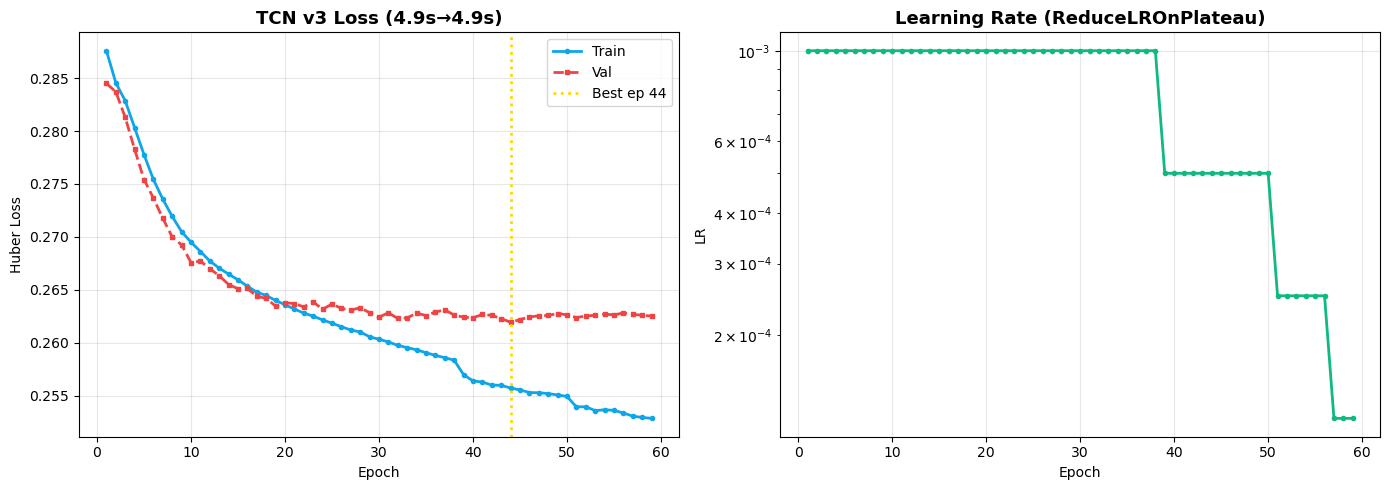

✅ Saved 01_training_history.png


In [8]:
# CELL 8 — TRAINING HISTORY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], color='#0ea5e9', lw=2, label='Train', marker='o', ms=3)
axes[0].plot(ep, history['val_loss'],   color='#ef4444', lw=2, label='Val',   marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss']))+1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
axes[0].set_title(f'TCN v3 Loss ({INPUT_LEN/FS:.1f}s→{HORIZON/FS:.1f}s)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['lr'], color='#10b981', lw=2, marker='o', ms=3)
axes[1].set_title('Learning Rate (ReduceLROnPlateau)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 01_training_history.png")

In [9]:
# CELL 9 — TEST EVALUATION
criterion = nn.HuberLoss(delta=0.5)
test_loss, test_preds, test_targets = eval_epoch(model, tcn_te, criterion, DEVICE)
print(f"Test Loss (Huber): {test_loss:.6f}")

mae_per_lead, rmse_per_lead = [], []
for i in range(N_LEADS):
    p = test_preds[:, :, i].flatten()
    t = test_targets[:, :, i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))

print(f"\nPer-Lead MAE:")
for i, name in enumerate(LEAD_NAMES):
    print(f"  {name:>4s}: MAE={mae_per_lead[i]:.4f}  RMSE={rmse_per_lead[i]:.4f}")
print(f"\nMacro MAE  : {np.mean(mae_per_lead):.6f}")
print(f"Macro RMSE : {np.mean(rmse_per_lead):.6f}")
print("✅ Evaluation complete")

Test Loss (Huber): 0.262902

Per-Lead MAE:
     I: MAE=0.7330  RMSE=1.1005
    II: MAE=0.6840  RMSE=1.0384
   III: MAE=0.6935  RMSE=1.0644
   aVR: MAE=0.6980  RMSE=1.0497
   aVL: MAE=0.7273  RMSE=1.1039
   aVF: MAE=0.6838  RMSE=1.0470
    V1: MAE=0.7672  RMSE=1.1628
    V2: MAE=0.7223  RMSE=1.1384
    V3: MAE=0.7153  RMSE=1.1358
    V4: MAE=0.7080  RMSE=1.1311
    V5: MAE=0.7216  RMSE=1.1311
    V6: MAE=0.7375  RMSE=1.1318

Macro MAE  : 0.715958
Macro RMSE : 1.102925
✅ Evaluation complete


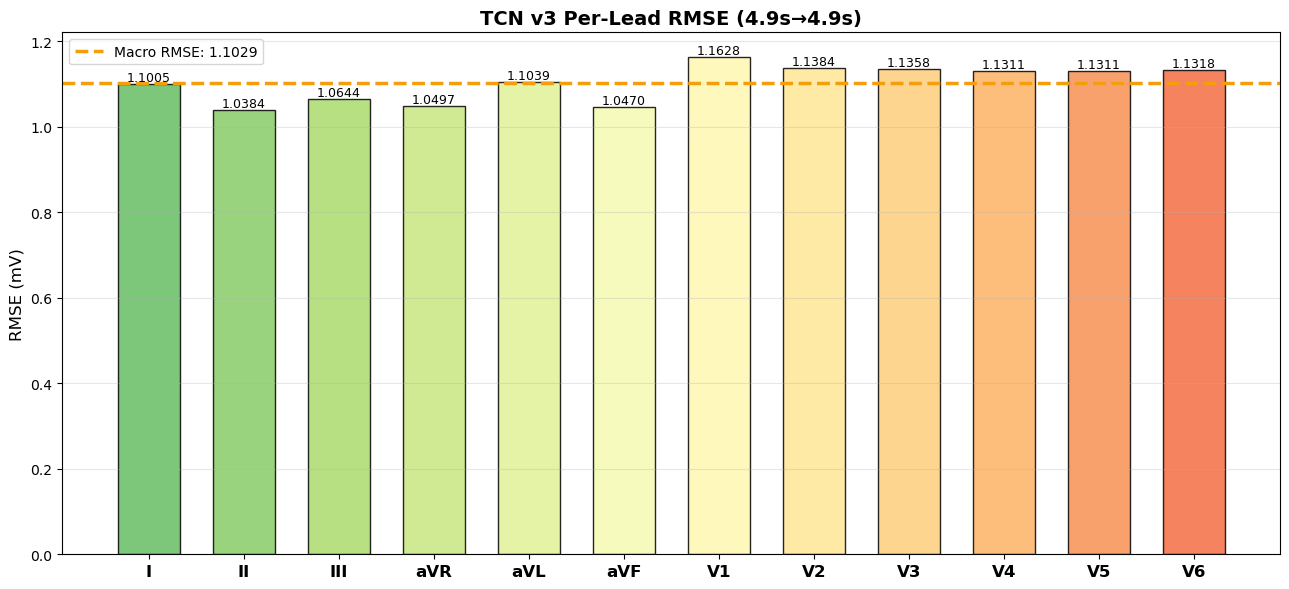

In [10]:
# CELL 10 — PER-LEAD RMSE
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, N_LEADS))
bars   = ax.bar(np.arange(N_LEADS), rmse_per_lead, width=0.65,
                color=colors, alpha=0.85, edgecolor='black')
ax.axhline(np.mean(rmse_per_lead), color='#f59e0b', ls='--', lw=2.5,
           label=f'Macro RMSE: {np.mean(rmse_per_lead):.4f}')
for bar, val in zip(bars, rmse_per_lead):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(np.arange(N_LEADS)); ax.set_xticklabels(LEAD_NAMES, fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (mV)', fontsize=12)
ax.set_title(f'TCN v3 Per-Lead RMSE ({INPUT_LEN/FS:.1f}s→{HORIZON/FS:.1f}s)',
             fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_per_lead_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

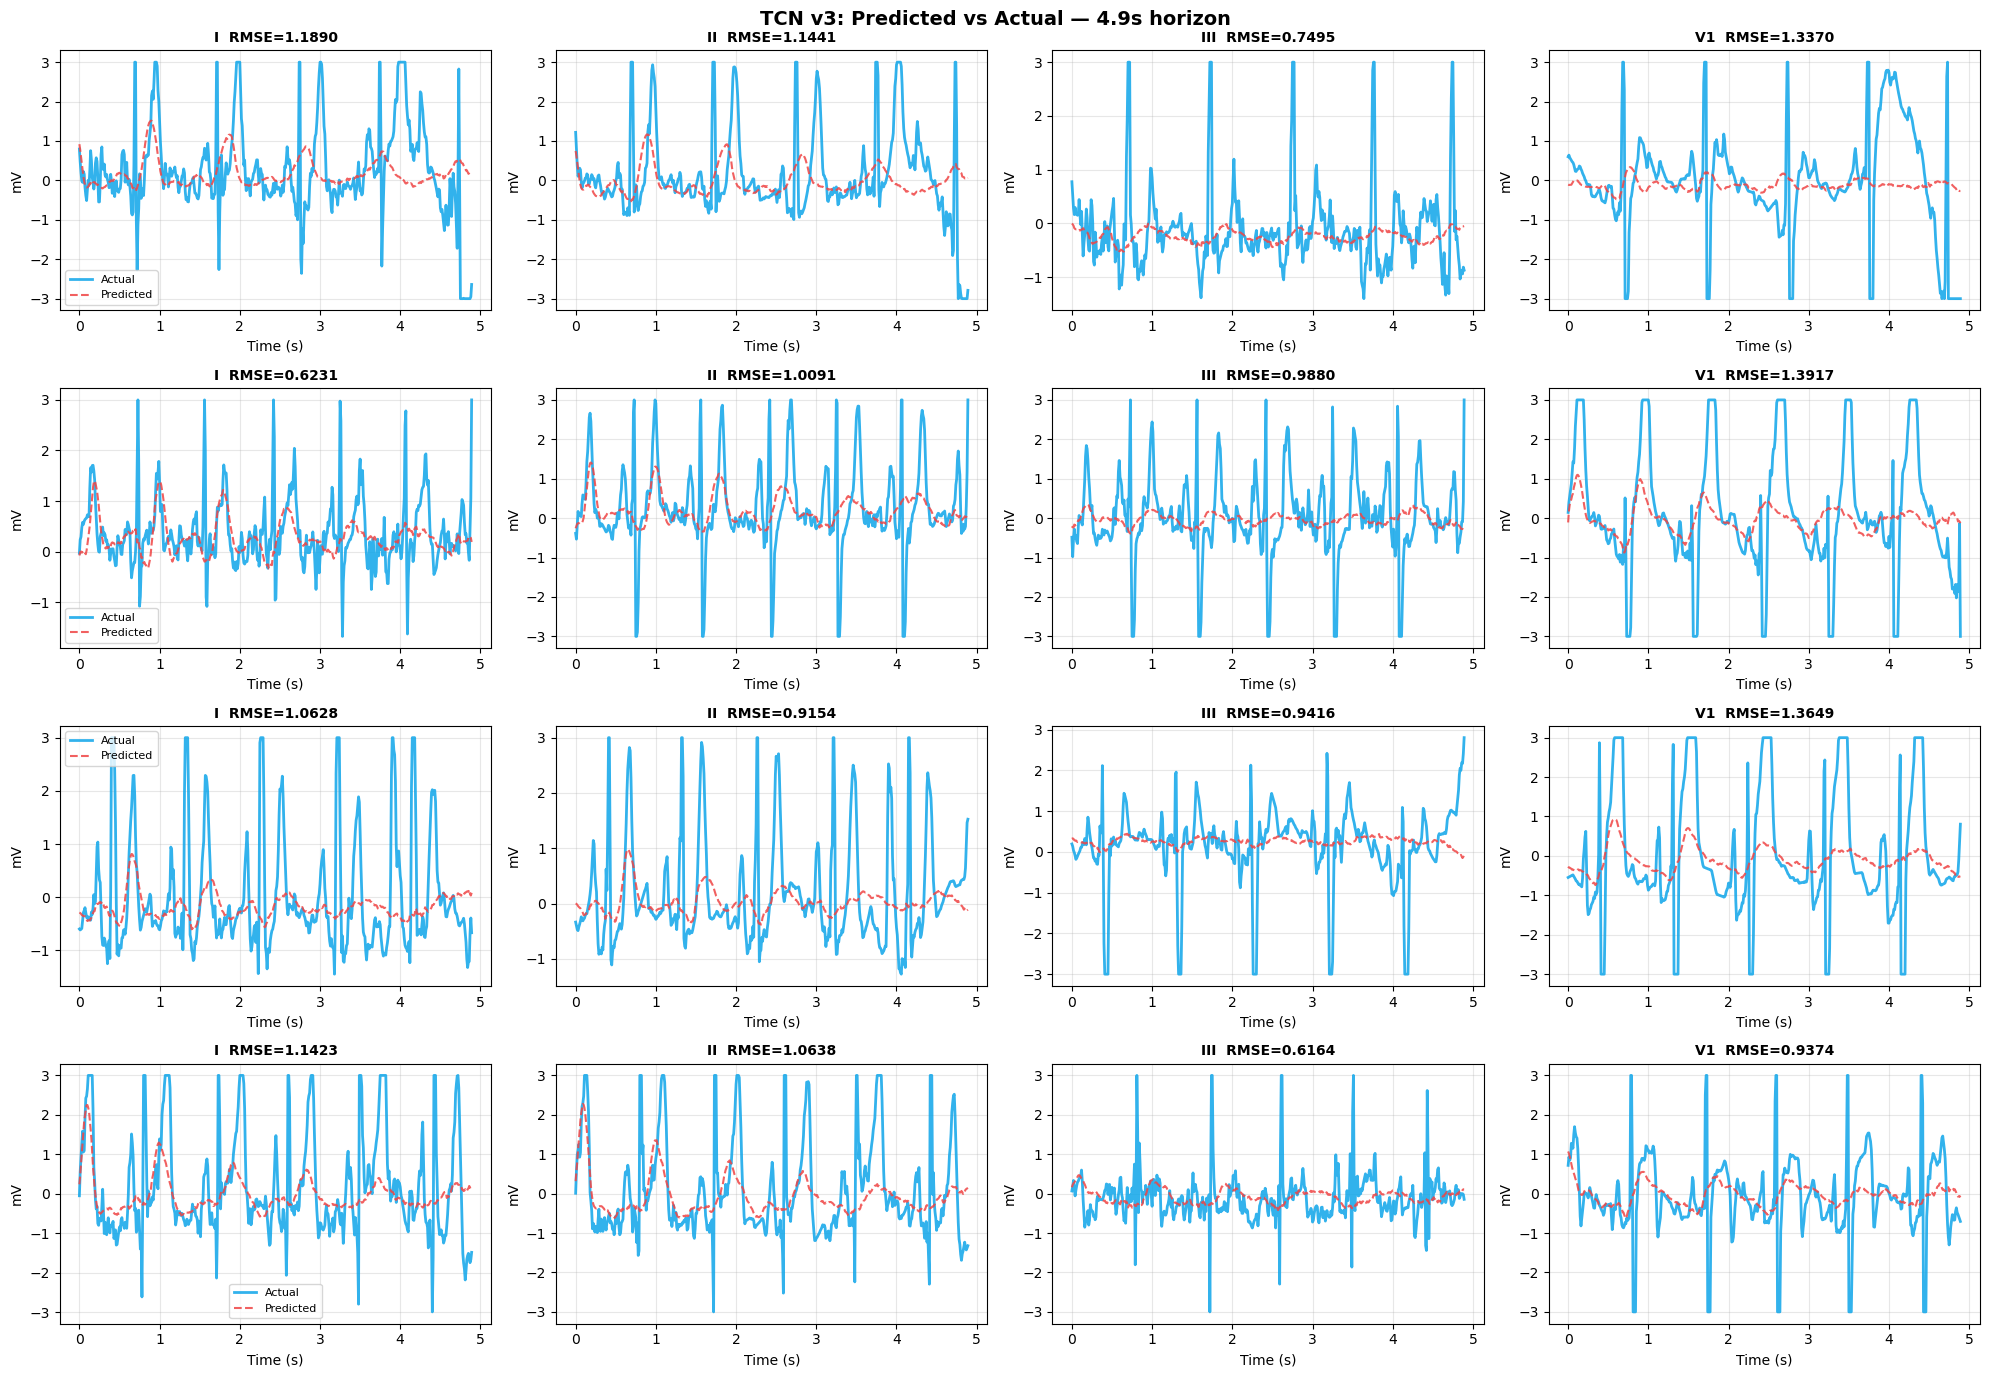

✅ Overlay saved


In [11]:
# CELL 11 — PREDICTED vs ACTUAL
n_samples    = 4
lead_indices = [0, 1, 2, 6]
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(n_samples, 4, figsize=(20, 14))
for row in range(n_samples):
    for col, lead_idx in enumerate(lead_indices):
        ax = axes[row, col]
        ax.plot(t, test_targets[row, :, lead_idx],
                color='#0ea5e9', lw=2, label='Actual', alpha=0.85)
        ax.plot(t, test_preds[row, :, lead_idx],
                color='#ef4444', lw=1.5, label='Predicted', ls='--', alpha=0.85)
        rmse_i = np.sqrt(mean_squared_error(
            test_targets[row,:,lead_idx], test_preds[row,:,lead_idx]))
        ax.set_title(f'{LEAD_NAMES[lead_idx]}  RMSE={rmse_i:.4f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.grid(True, alpha=0.3)
        if col == 0: ax.legend(fontsize=8)

fig.suptitle(f'TCN v3: Predicted vs Actual — {HORIZON/FS:.1f}s horizon',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Overlay saved")

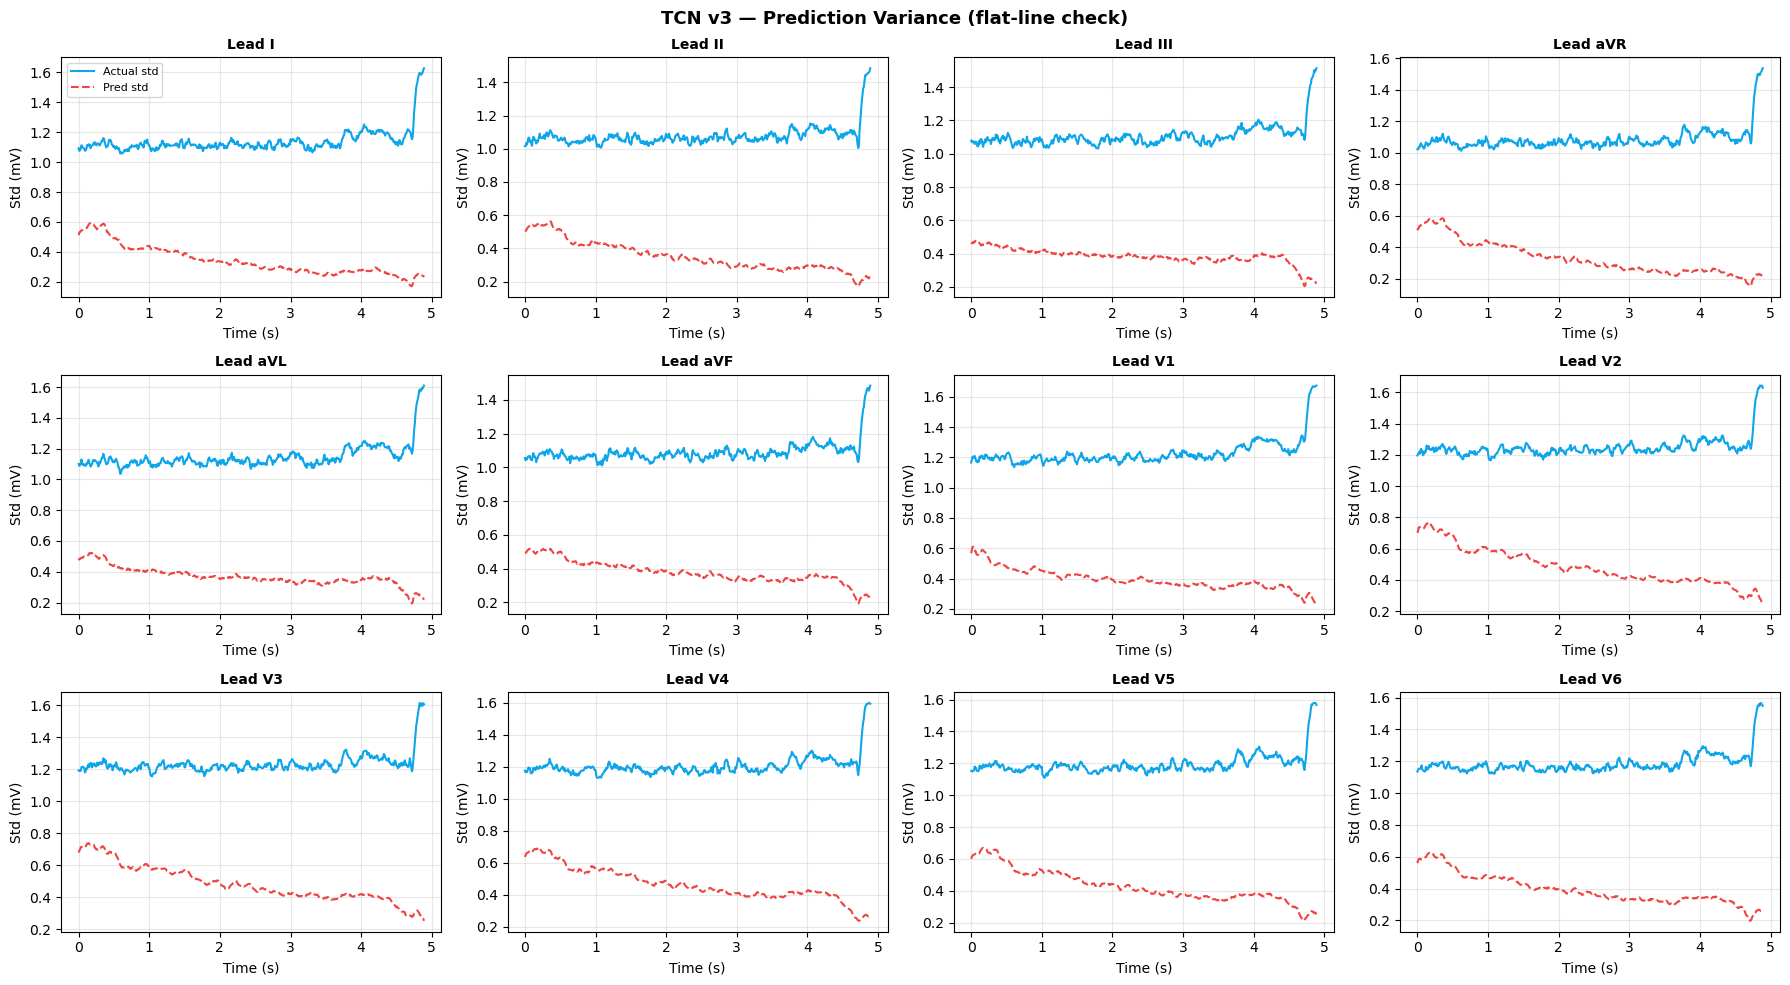

✅ No flat-line. Min pred std = 0.1546


In [12]:
# CELL 12 — FLAT-LINE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
flat_leads = []
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t, true_std[:, i],  color='#0ea5e9', lw=1.5, label='Actual std')
    ax.plot(t, pred_std[:, i],  color='#ef4444', lw=1.5, label='Pred std',  ls='--')
    ax.set_title(f'Lead {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Std (mV)'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=8)
    if pred_std[:, i].min() < 0.01:
        ax.set_facecolor('#fff0f0')
        flat_leads.append(name)
        ax.set_title(f'Lead {name} ⚠ flat?', color='red', fontweight='bold', fontsize=10)

fig.suptitle('TCN v3 — Prediction Variance (flat-line check)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_flatline_check.png'), dpi=150, bbox_inches='tight')
plt.show()

if flat_leads:
    print(f"⚠ Possibly flat leads: {flat_leads}")
else:
    print(f"✅ No flat-line. Min pred std = {pred_std.min():.4f}")

In [13]:
# CELL 13 — SAVE RESULTS
results = {
    'model': 'TCN_v3', 'horizon_s': HORIZON/FS, 'input_s': INPUT_LEN/FS,
    'n_parameters': n_params, 'test_loss': test_loss,
    'mae_per_lead': mae_per_lead, 'mae_macro': np.mean(mae_per_lead),
    'rmse_per_lead': rmse_per_lead, 'rmse_macro': np.mean(rmse_per_lead),
    'history': history, 'lead_names': LEAD_NAMES,
    'test_preds': test_preds, 'test_targets': test_targets,
}
path = os.path.join(CKPT_DIR, 'TCN_results_summary.pkl')
with open(path, 'wb') as f: pickle.dump(results, f)

print(f"{'='*60}")
print(f"  TCN v3 FINAL RESULTS  ({INPUT_LEN/FS:.1f}s → {HORIZON/FS:.1f}s)")
print(f"{'='*60}")
print(f"  Parameters : {n_params:,}")
print(f"  Test Loss  : {test_loss:.6f}")
print(f"  Macro MAE  : {np.mean(mae_per_lead):.6f} mV")
print(f"  Macro RMSE : {np.mean(rmse_per_lead):.6f} mV")
print(f"  Saved      → {path}")
print("✅ TCN v3 Complete!")

  TCN v3 FINAL RESULTS  (4.9s → 4.9s)
  Parameters : 1,807,563
  Test Loss  : 0.262902
  Macro MAE  : 0.715958 mV
  Macro RMSE : 1.102925 mV
  Saved      → ../reports/checkpoints/TCN_results_summary.pkl
✅ TCN v3 Complete!
